# 30 — Attention Intuition and Weighted Retrieval

A recurrent model compresses earlier information into a state that is updated step by step. Attention offers another operation: compare a query with a collection of keys, then retrieve a weighted mixture of their values.

This notebook develops that idea with tiny vectors before introducing scaled, batched, or multi-head attention.

## Learning objectives

- distinguish queries, keys, and values;
- calculate dot-product similarity scores;
- turn scores into attention weights with stable softmax;
- compute a weighted retrieval from values;
- extend one-query attention to several queries with matrix multiplication;
- exclude unavailable positions with an attention mask;
- interpret attention weights without treating them as a complete explanation.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

np.set_printoptions(precision=3, suppress=True)


## 1. Query, keys, and values

Think of attention as differentiable retrieval:

- a **query** describes what information is currently needed;
- each **key** describes what one stored item is relevant to;
- each **value** contains the information returned from that item.

Keys and values occur in corresponding rows, but they have different roles. A key is used for matching; its value is used to construct the result. They may even have different feature dimensions.

For one query $q\in\mathbb{R}^{D_k}$ and $M$ keys $K\in\mathbb{R}^{M\times D_k}$, dot-product scores are

$$
s=Kq,
$$

with shape $(M,)$. A larger score means stronger alignment under the current representations.

### Exercise 1 — Calculate one query's similarity scores


In [ ]:
labels = ["horizontal", "vertical", "diagonal", "opposite"]
query = np.array([1.0, 0.2])
keys = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [0.7, 0.7],
    [-1.0, 0.0],
])
values = np.array([
    [10.0, 0.0, 0.0],
    [0.0, 10.0, 0.0],
    [0.0, 0.0, 10.0],
    [-5.0, -5.0, -5.0],
])

# compute one dot-product score per key without a Python loop.
scores = keys.dot(query) # keys @ query

assert scores.shape == (4,)
np.testing.assert_allclose(scores, [1.0, 0.2, 0.84, -1.0])
for label, score in zip(labels, scores):
    print(f"{label:>10}: {score: .2f}")


horizontal:  1.00
  vertical:  0.20
  diagonal:  0.84
  opposite: -1.00


## 2. From scores to a weighted retrieval

Raw scores are not yet mixture weights. Softmax converts them into nonnegative values that sum to one:

$$
\alpha_i=\frac{e^{s_i}}{\sum_j e^{s_j}}.
$$

The attention output is the weighted sum of the value rows:

$$
o=\sum_i\alpha_iV_i=\alpha V.
$$

With $V:(M,D_v)$, the result has shape $(D_v,)$. Attention usually returns a blend, not simply the value with the largest score.

### Exercise 2 — Implement stable softmax and retrieve the value mixture


In [20]:
def softmax_1d(scores):
    """Convert one vector of scores into stable probabilities."""
    # subtract the maximum, exponentiate, and normalize.
    scores_shifted = scores - np.max(scores) # - scores.max(axis=0)
    shifted_exp = np.exp(scores_shifted)
    output = shifted_exp / np.sum(shifted_exp)
    return output


attention_weights = softmax_1d(scores)
# combine the values using the attention weights.
retrieved = attention_weights @ values

assert attention_weights.shape == (4,)
assert retrieved.shape == (3,)
np.testing.assert_allclose(attention_weights.sum(), 1.0)
assert np.all(attention_weights >= 0.0)
np.testing.assert_allclose(retrieved, attention_weights @ values)
print("weights:", attention_weights)
print("retrieved value:", retrieved)


weights: [0.41  0.184 0.35  0.056]
retrieved value: [3.826 1.566 3.219]


## 3. Visualizing focus and score sharpness

Multiplying all scores by a positive factor preserves their order but changes softmax sharpness. Larger magnitudes make the largest score dominate; smaller magnitudes make the distribution more uniform. Notebook 31 will connect this sensitivity to the $\sqrt{D_k}$ scaling used in dot-product attention.

### Exercise 3 — Compare three score scales


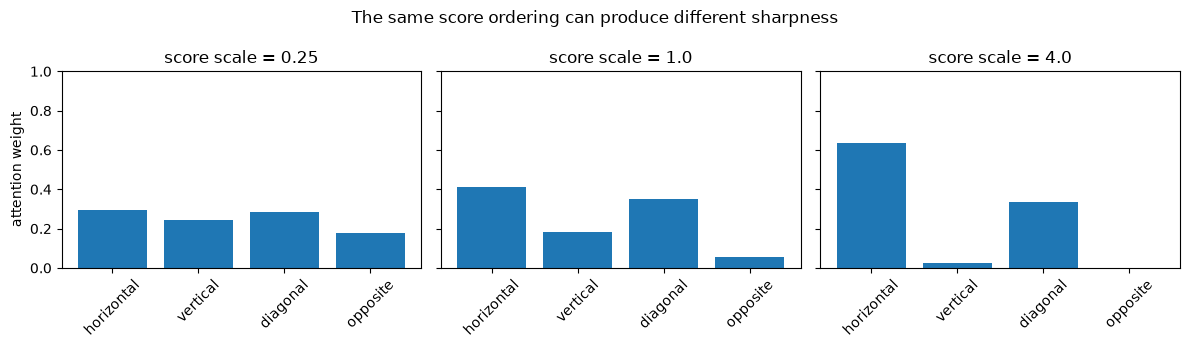

In [21]:
score_scales = [0.25, 1.0, 4.0]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)

for axis, scale in zip(axes, score_scales):
    # obtain weights from the scaled scores.
    weights_at_scale = softmax_1d(scale * scores)
    axis.bar(labels, weights_at_scale)
    axis.set_title(f"score scale = {scale}")
    axis.tick_params(axis="x", rotation=45)
    axis.set_ylim(0.0, 1.0)

axes[0].set_ylabel("attention weight")
fig.suptitle("The same score ordering can produce different sharpness")
plt.tight_layout()
plt.show()


## 4. Several queries: the matrix form

For $L$ queries collected in $Q:(L,D_k)$, every query is compared with every key at once:

$$
S=QK^T.
$$

The score matrix has shape $(L,M)$. Row $l$ contains the scores from query $l$ to all $M$ keys. Softmax must therefore operate independently across the key axis of each row. The outputs are

$$
A=\mathrm{softmax}_{rows}(S),\qquad O=AV,
$$

with $A:(L,M)$ and $O:(L,D_v)$. Here `softmax_rows` is descriptive notation; the implementation uses an explicit axis rather than a custom LaTeX operator.

### Exercise 4 — Vectorize attention for multiple queries


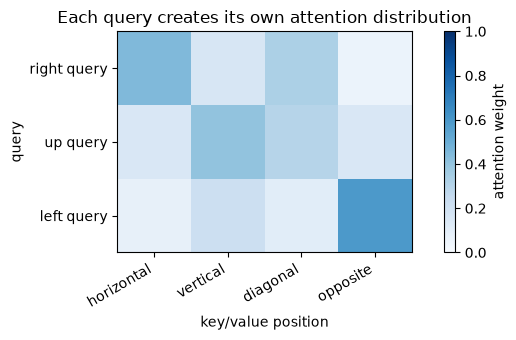

In [23]:
def softmax_rows(score_matrix):
    """Apply stable softmax independently to every matrix row."""
    # Keep a singleton column so one maximum broadcasts across each row.
    shifted = score_matrix - score_matrix.max(axis=1, keepdims=True)
    shifted_exp = np.exp(shifted)
    # The denominator also needs shape (num_queries, 1), not
    # (num_queries,), so every row is normalized independently.
    output = shifted_exp / np.sum(shifted_exp, axis=1, keepdims=True)
    return output


queries = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [-1.0, 0.0],
])

# Each query row is compared with every key row:
# (3, 2) @ (2, 4) -> (3, 4).
score_matrix = queries @ keys.T
weight_matrix = softmax_rows(score_matrix)
attention_outputs = weight_matrix @ values

assert score_matrix.shape == weight_matrix.shape == (3, 4)
assert attention_outputs.shape == (3, 3)
np.testing.assert_allclose(weight_matrix.sum(axis=1), 1.0)

fig, ax = plt.subplots(figsize=(7, 3.5))
image = ax.imshow(weight_matrix, cmap="Blues", vmin=0.0, vmax=1.0)
ax.set_xticks(range(len(labels)), labels=labels, rotation=30, ha="right")
ax.set_yticks(range(len(queries)), labels=["right query", "up query", "left query"])
ax.set_xlabel("key/value position")
ax.set_ylabel("query")
ax.set_title("Each query creates its own attention distribution")
fig.colorbar(image, ax=ax, label="attention weight")
plt.tight_layout()
plt.show()


In [33]:
score_matrix.max(axis=1), score_matrix.max(axis=1, keepdims=True)

(array([1., 1., 1.]),
 array([[1.],
        [1.],
        [1.]]))

In [35]:
score_matrix, score_matrix - score_matrix.max(axis=1, keepdims=True)

(array([[ 1. ,  0. ,  0.7, -1. ],
        [ 0. ,  1. ,  0.7,  0. ],
        [-1. ,  0. , -0.7,  1. ]]),
 array([[ 0. , -1. , -0.3, -2. ],
        [-1. ,  0. , -0.3, -1. ],
        [-2. , -1. , -1.7,  0. ]]))

## 5. Attention masks

A mask identifies key positions that a query is not allowed to use. Examples include padding tokens and, in autoregressive decoding, future tokens.

Masking must happen **before softmax**. Replacing forbidden scores with negative infinity makes their exponentials zero, so valid positions are renormalized to sum to one. Multiplying probabilities by zero after softmax would leave the remaining probabilities summing to less than one unless they were normalized again.

### Exercise 5 — Exclude one stored position


In [36]:
valid_keys = np.array([True, True, False, True])
valid_keys == False

array([False, False,  True, False])

In [40]:
valid_keys = np.array([True, True, False, True])

def masked_attention_one_query(query, keys, values, valid_keys):
    """Attend with one query while excluding invalid key rows."""
    # One query creates one score for every key: (D_k,) @ (D_k, M).
    scores = query @ keys.T

    # ~valid_keys is True exactly where a key must be excluded. Setting
    # those scores to -infinity makes their exponentials equal zero.
    masked_scores = scores.copy()
    masked_scores[~valid_keys] = -np.inf

    # This is one-dimensional attention, so reuse softmax_1d rather than
    # the row-wise matrix helper from Exercise 4.
    weights = softmax_1d(masked_scores)
    output = weights @ values
    return output, weights


masked_output, masked_weights = masked_attention_one_query(
    query, keys, values, valid_keys
)
assert masked_output.shape == (3,)
assert masked_weights.shape == (4,)
assert masked_weights[2] == 0.0
np.testing.assert_allclose(masked_weights.sum(), 1.0)
print("masked weights:", masked_weights)
print("masked output:", masked_output)


masked weights: [0.631 0.284 0.    0.085]
masked output: [ 5.883  2.408 -0.427]


## 6. Attention as soft retrieval

Compare attention with nearest-neighbor retrieval from our earlier practice:

- hard nearest-neighbor retrieval selects one or a few stored examples;
- attention assigns differentiable weights and returns a value mixture;
- learned models transform raw inputs into queries, keys, and values so useful matching behavior can emerge during training.

A high attention weight indicates that one position strongly affected this retrieval operation. It does not prove that the position is the sole reason for the model's final prediction: projections, residual paths, later layers, and other heads may also contribute.

### Exercise 6 — Brief interpretation

In two or three sentences, explain why attention is differentiable while `argmax` retrieval is not, and why a weighted mixture may be useful.

**Answer:**  
Softmax changes smoothly when its scores change, so gradients can flow through the attention weights into queries, keys, and values. `argmax` makes a discrete selection that is constant across most small score changes and jumps when the winning index changes, so it has no useful ordinary gradient. A weighted mixture can preserve and combine information from several relevant values instead of discarding every value except one.

## 7. Reflection

1. What different jobs do a key and its corresponding value perform?
2. Why must a query and key have compatible feature dimensions?
3. Why do attention weights sum to one?
4. Is an attention output normally one selected value or a mixture?
5. In $QK^T$, what do the row and column axes of the result represent?
6. Along which axis should softmax operate in the score matrix, and why?
7. Why should invalid scores be masked before softmax?
8. Why should attention weights be interpreted cautiously?

### Answers

1. A key is compared with the query to determine relevance. Its corresponding value contains the information that is retrieved.
2. Their dimensions must match so their dot product is defined and compares corresponding features.
3. The scores are passed through softmax, which normalizes positive exponentials by their sum.
4. It is normally a weighted mixture of the value rows, using the softmax attention weights.
5. Each row represents one query, and each column represents one key. Entry $(l,m)$ is the score between query $l$ and key $m$.
6. Softmax operates across the key columns (`axis=1`) independently for each query row, because every query needs its own distribution over the available keys.
7. Masking before softmax gives forbidden positions zero exponential weight and renormalizes the valid positions to sum to one.
8. A weight describes influence inside this particular retrieval operation, not the complete reason for the final prediction. Value projections, residual paths, later layers, and other attention heads can also affect the result.
